=== Initializing H-ORG HOAF Visual Simulation ===
Generating Object Components...
Profiling: Pure Amplitude
(Thin Stained Slice)...
Profiling: Weak Pure Phase
(Thin Transparent Cell)...
Profiling: Strong Pure Phase
(Thick Transparent Tissue)...
Profiling: Complex Object
(Thick Stained Tissue)...

Rendering HOAF Dashboard...


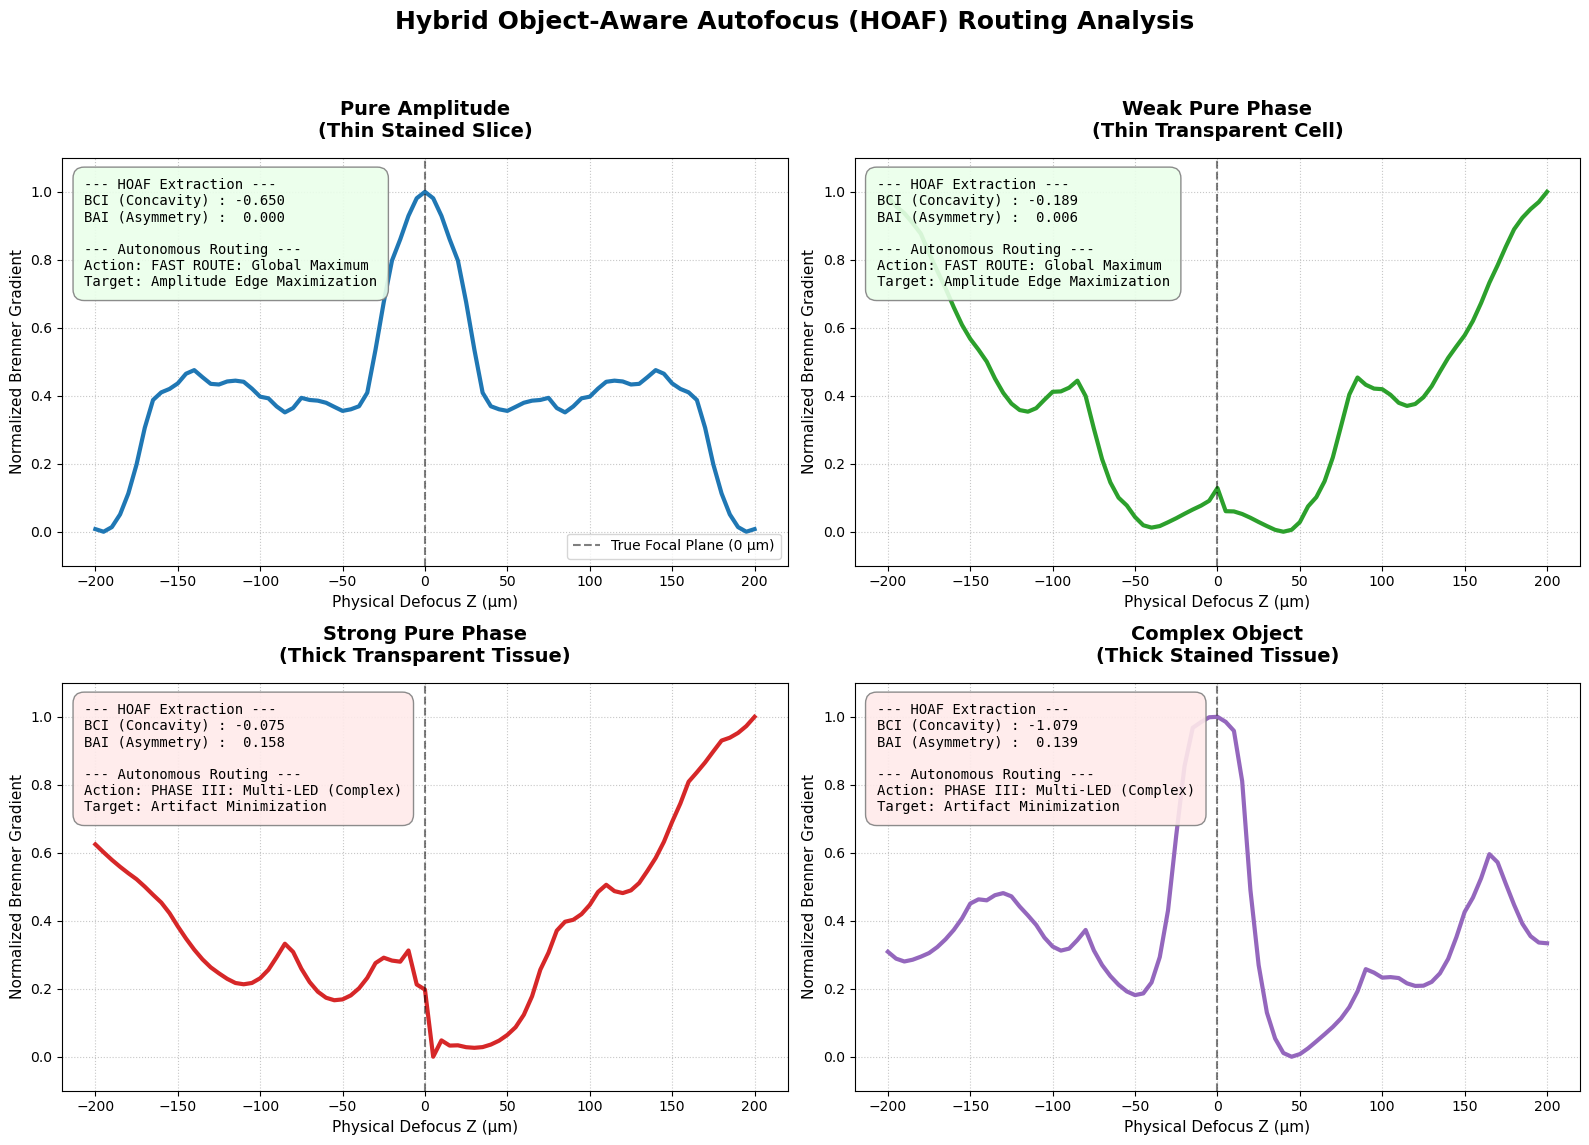

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import time

# ==========================================
# 1. Core Functions & HOAF Class
# ==========================================
def brenner_gradient(image):
    """Calculates the high-frequency contrast metric."""
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    dx = np.sum((img_norm[2:, :] - img_norm[:-2, :])**2)
    dy = np.sum((img_norm[:, 2:] - img_norm[:, :-2])**2)
    return dx + dy

class HOAF_Framework:
    """Hybrid Object-Aware Autofocus (HOAF) Engine"""
    def __init__(self, NA=0.1, wavelength=0.532e-3, mag=2.0, pixel_size=2.5e-3):
        self.NA = NA
        self.wl = wavelength
        self.dx = pixel_size / mag
        self.k0 = 2 * np.pi / wavelength
        self.cutoff = NA / wavelength

    def phase_1_rapid_profiler(self, O_fourier, z_array, pupil_support, kz, N_lr):
        """Phase I: Fast Central-LED Z-Sweep"""
        cy, cx = O_fourier.shape[0]//2, O_fourier.shape[1]//2
        ys, ye = cy - N_lr//2, cy + N_lr//2
        xs, xe = cx - N_lr//2, cx + N_lr//2
        
        scores = []
        for z in z_array:
            pupil_z = pupil_support * np.exp(1j * z * kz)
            E_fourier = O_fourier[ys:ye, xs:xe] * pupil_z
            E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
            scores.append(brenner_gradient(np.abs(E_spatial)**2))
            
        return np.array(scores)

    def phase_2_logic_gate(self, scores):
        """Phase II: Extracts BCI & BAI to route the autofocus."""
        # Normalize scores for consistent thresholding
        b = (scores - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-8)
        c_idx = len(b) // 2
        
        # 1. Brenner Concavity Index (BCI)
        # Sample slightly off-center to avoid digital noise spikes
        b_left = b[c_idx - 5]
        b_right = b[c_idx + 5]
        b_center = b[c_idx]
        bci = (b_left + b_right - 2 * b_center)
        
        # 2. Brenner Asymmetry Index (BAI)
        left_area = np.sum(b[:c_idx])
        right_area = np.sum(b[c_idx+1:])
        bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
        
        # HOAF Routing Logic
        asymmetry_threshold = 0.05
        
        if bai > asymmetry_threshold:
            route = "PHASE III: Multi-LED (Complex)"
            focus_type = "Artifact Minimization"
        elif bci < -0.1:
            route = "FAST ROUTE: Global Maximum"
            focus_type = "Amplitude Edge Maximization"
        elif bci > 0.1:
            route = "FAST ROUTE: Global Minimum"
            focus_type = "Phase Fringe Minimization"
        else:
            route = "PHASE III: Multi-LED (Strong Phase)"
            focus_type = "Artifact Minimization"
            
        return b, bci, bai, route, focus_type

# ==========================================
# 2. Main Simulation execution
# ==========================================
def simulate_hoaf_visual_results():
    print("=== Initializing H-ORG HOAF Visual Simulation ===")
    
    # Initialize Framework
    hoaf = HOAF_Framework()
    
    # Grid Setup
    N_hr = 256
    N_lr = 64
    
    # Generate Ground Truth Components
    print("Generating Object Components...")
    img_amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    
    img_phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    
    # The 4 distinct physical test cases
    test_objects = {
        "Pure Amplitude\n(Thin Stained Slice)": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Pure Phase\n(Thin Transparent Cell)": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.1)),
        "Strong Pure Phase\n(Thick Transparent Tissue)": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 3.0)),
        "Complex Object\n(Thick Stained Tissue)": img_amp * np.exp(1j * (img_phase_smooth * 1.5))
    }
    
    # Setup Fourier Geometry
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=hoaf.dx))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=hoaf.dx))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    pupil_support = (np.sqrt(FX_lr**2 + FY_lr**2) <= hoaf.cutoff).astype(float)
    radicand = np.maximum((1/hoaf.wl)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    
    # Sweep from -200um to +200um
    z_array = np.linspace(-0.200, 0.200, 81)
    
    results = {}
    
    for name, obj in test_objects.items():
        print(f"Profiling: {name.split('\\n')[0]}...")
        O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
        
        # Run HOAF
        raw_scores = hoaf.phase_1_rapid_profiler(O_fourier, z_array, pupil_support, kz, N_lr)
        norm_scores, bci, bai, route, focus_type = hoaf.phase_2_logic_gate(raw_scores)
        
        results[name] = {
            "scores": norm_scores,
            "bci": bci,
            "bai": bai,
            "route": route,
            "focus": focus_type
        }

    # ==========================================
    # 3. Comprehensive Plotting
    # ==========================================
    print("\nRendering HOAF Dashboard...")
    plt.figure(figsize=(16, 12))
    plt.suptitle("Hybrid Object-Aware Autofocus (HOAF) Routing Analysis", fontsize=18, fontweight='bold', y=0.98)
    
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, (name, res_data) in enumerate(results.items()):
        ax = plt.subplot(2, 2, idx+1)
        
        # Plot the profiling curve
        ax.plot(z_array * 1000, res_data["scores"], color=colors[idx], linewidth=3)
        ax.axvline(0, color='k', linestyle='--', alpha=0.5, label='True Focal Plane (0 µm)')
        
        ax.set_title(name, fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Physical Defocus Z (µm)", fontsize=11)
        ax.set_ylabel("Normalized Brenner Gradient", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_ylim(-0.1, 1.1)
        
        # Text Box containing the HOAF Algorithmic Decision
        decision_text = (
            f"--- HOAF Extraction ---\n"
            f"BCI (Concavity) : {res_data['bci']:>6.3f}\n"
            f"BAI (Asymmetry) : {res_data['bai']:>6.3f}\n\n"
            f"--- Autonomous Routing ---\n"
            f"Action: {res_data['route']}\n"
            f"Target: {res_data['focus']}"
        )
        
        # Dynamic box coloring based on routing
        box_color = '#eaffea' if 'FAST ROUTE' in res_data['route'] else '#ffeaea'
        
        props = dict(boxstyle='round,pad=0.8', facecolor=box_color, alpha=0.9, edgecolor='gray')
        ax.text(0.03, 0.95, decision_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', family='monospace', bbox=props)
                
        if idx == 0:
            ax.legend(loc='lower right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    simulate_hoaf_visual_results()

Initializing Brenner Topology Framework Demonstration...
Processing: 1. Pure Amplitude...
Processing: 2. Weak Pure Phase...
Processing: 3. Strong Pure Phase...
Processing: 4. Sharp Pure Phase...
Processing: 5. Complex: Amp + Weak Phase...
Processing: 6. Complex: Amp + Strong Phase...

Rendering Presentation Grid...


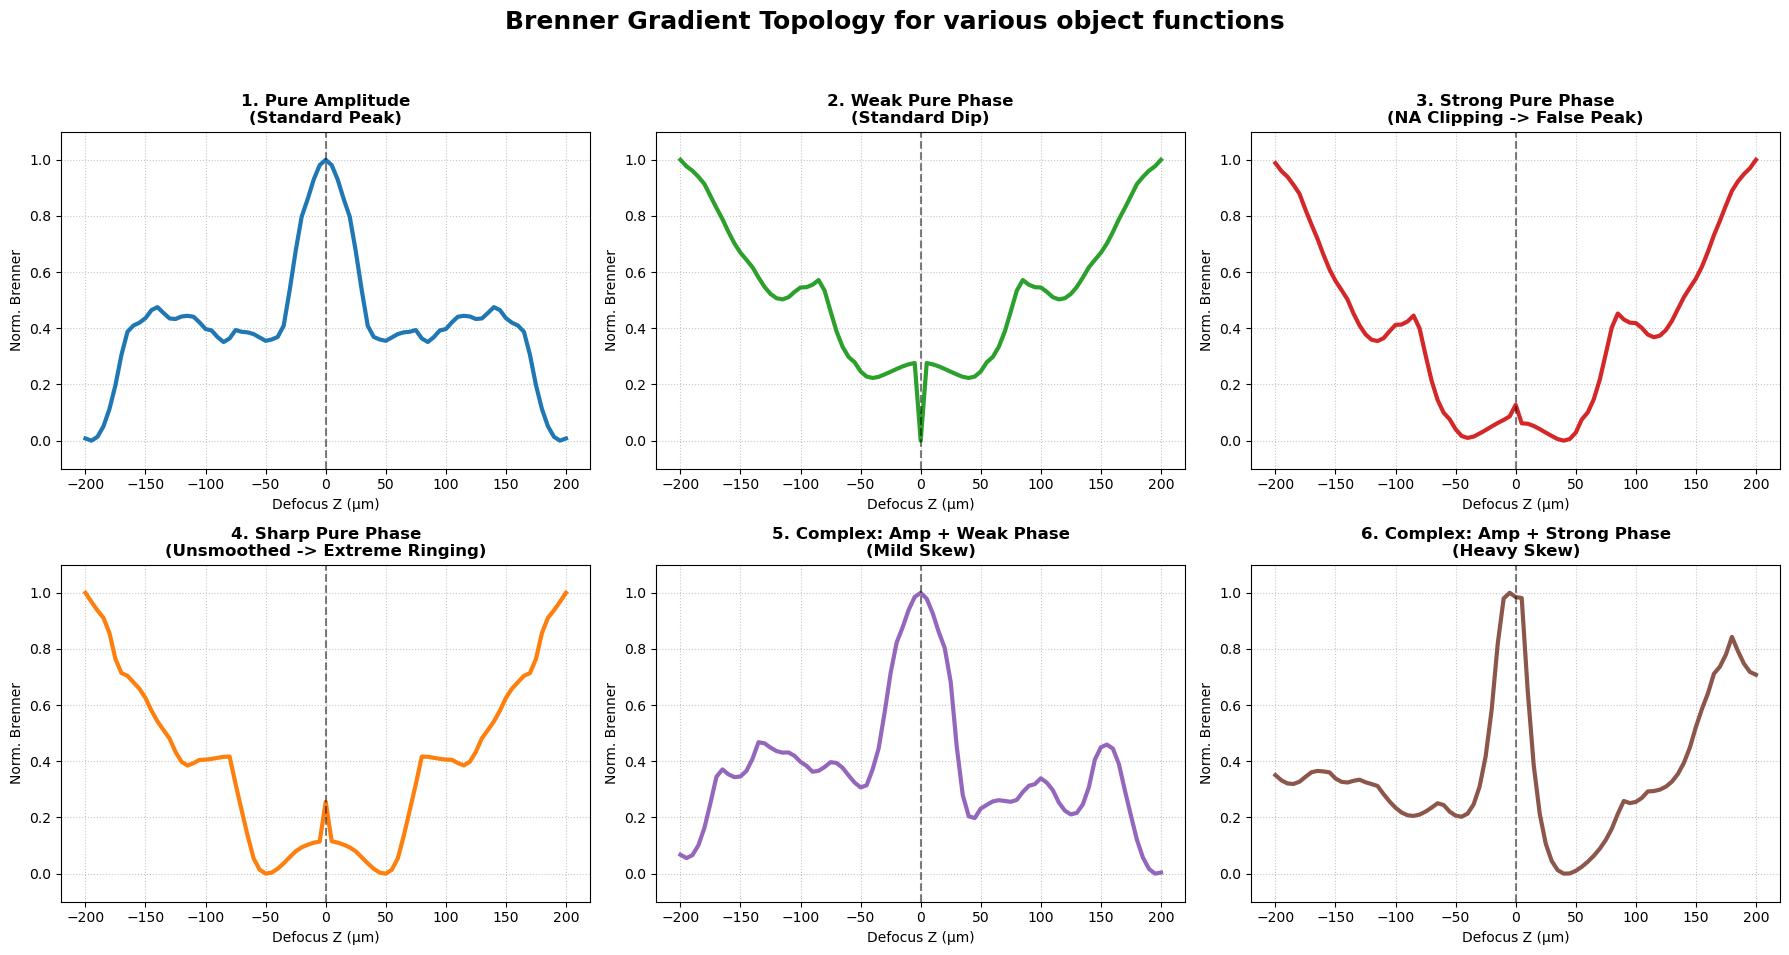

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter

# ====================================================================
# 1. Core Mathematical Metrics (The Brains of the Framework)
# ====================================================================
def calculate_brenner(image):
    """Calculates the high-frequency contrast metric for a 2D intensity image."""
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    dx = np.sum((img_norm[2:, :] - img_norm[:-2, :])**2)
    dy = np.sum((img_norm[:, 2:] - img_norm[:, :-2])**2)
    return dx + dy

def extract_bci_bai(z_array, brenner_scores):
    """
    Extracts the geometric topology indices from a Z-sweep Brenner curve.
    """
    # Normalize scores between 0 and 1 for scale-invariant thresholds
    b = (brenner_scores - np.min(brenner_scores)) / (np.max(brenner_scores) - np.min(brenner_scores) + 1e-8)
    center_idx = len(z_array) // 2
    
    # 1. Brenner Concavity Index (BCI) - 2nd Derivative Approximation
    # We sample +/- 5 steps (e.g., +/- 25 um) to avoid discrete focal noise
    b_left = b[center_idx - 5]
    b_right = b[center_idx + 5]
    b_center = b[center_idx]
    bci = (b_left + b_right - 2 * b_center)
    
    # 2. Brenner Asymmetry Index (BAI) - Skewness
    left_area = np.sum(b[:center_idx])
    right_area = np.sum(b[center_idx+1:])
    bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
    
    # 3. Autonomous Classification Logic
    if bai > 0.05:
        classification = "Complex (Asymmetric)"
    elif bci < -0.1:
        classification = "Amplitude / Strong Phase (Peak)"
    elif bci > 0.1:
        classification = "Weak Phase (Dip)"
    else:
        classification = "Ambiguous / Flat"
        
    return b, bci, bai, classification

# ====================================================================
# 2. The Optical Simulator
# ====================================================================
def run_framework_demonstration():
    print("Initializing Brenner Topology Framework Demonstration...")
    
    # System Setup (Strictly in mm to prevent exponent scaling crashes)
    wavelength = 0.532e-3  
    NA_obj = 0.1           
    mag = 2.0              
    cam_pixel_size = 2.5e-3 
    dx_lr = cam_pixel_size / mag 
    
    N_hr = 256
    N_lr = 64
    dx_hr = dx_lr / 4

    # Generate Base Biological Features
    img_amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    
    img_phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)

    # ---------------------------------------------------------
    # THE 6 TEST SUBJECTS: Proving the Topology Variance
    # ---------------------------------------------------------
    objects = {
        "1. Pure Amplitude\n(Standard Peak)": 
            img_amp * np.exp(1j * np.zeros_like(img_amp)),
            
        "2. Weak Pure Phase\n(Standard Dip)": 
            np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.00005)),
            
        "3. Strong Pure Phase\n(NA Clipping -> False Peak)": 
            np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.08)),
            
        "4. Sharp Pure Phase\n(Unsmoothed -> Extreme Ringing)": 
            np.ones_like(img_amp) * np.exp(1j * (img_phase / np.max(img_phase) * 0.005)),
            
        "5. Complex: Amp + Weak Phase\n(Mild Skew)": 
            img_amp * np.exp(1j * (img_phase_smooth * 0.5)),
            
        "6. Complex: Amp + Strong Phase\n(Heavy Skew)": 
            img_amp* np.exp(1j * (img_phase_smooth * 3.0))
    }

    # Fourier Setup (Pupil and Defocus Matrix)
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    pupil_support = (np.sqrt(FX_lr**2 + FY_lr**2) <= NA_obj / wavelength).astype(float)
    kz = 2 * np.pi * np.sqrt(np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0))
    
    cy, cx = N_hr//2, N_hr//2
    ys, ye, xs, xe = cy - N_lr//2, cy + N_lr//2, cx - N_lr//2, cx + N_lr//2

    # Defocus Z-Sweep Array: -200um to +200um (81 steps)
    z_array = np.linspace(-0.200, 0.200, 81)
    results = {}

    # Run the Simulator
    for name, obj in objects.items():
        print(f"Processing: {name.splitlines()[0]}...")
        O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
        scores = []
        
        for z in z_array:
            pupil_z = pupil_support * np.exp(1j * z * kz)
            E_fourier = O_fourier[ys:ye, xs:xe] * pupil_z
            E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
            scores.append(calculate_brenner(np.abs(E_spatial)**2))
        
        # Extract framework parameters
        norm_scores, bci, bai, classification = extract_bci_bai(z_array, np.array(scores))
        results[name] = {"scores": norm_scores, "bci": bci, "bai": bai, "class": classification}

    # ====================================================================
    # 3. Presentation-Ready Visualization
    # ====================================================================
    print("\nRendering Presentation Grid...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Brenner Gradient Topology for various object functions", fontsize=18, fontweight='bold', y=0.98)
    
    axes = axes.flatten()
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']

    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        
        # Plot the curve
        ax.plot(z_array * 1000, res["scores"], color=colors[idx], linewidth=3)
        ax.axvline(0, color='k', linestyle='--', alpha=0.5)
        
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.set_xlabel("Defocus Z (µm)")
        ax.set_ylabel("Norm. Brenner")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_ylim(-0.1, 1.1)
        
        # Overlay the BCI and BAI Data Box


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    run_framework_demonstration()